In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("CICIDS2017_Combined.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (2830743, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6      

In [ ]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830742,53,94939,4,2,188,226,47,47,47.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [ ]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [ ]:
df.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

In [ ]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 1358


In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [ ]:
df.columns = df.columns.str.strip()
drop_cols = ["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Timestamp"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

In [ ]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (2827876, 78)
After removing duplicates: (2233164, 78)


In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y
)

In [ ]:
sample_size = 0.1

print(f"Original training data size: {X_train.shape[0]}")
print(f"Sampling {sample_size * 100}% of the training data for faster training.")

# Use stratified sampling to maintain class proportions in the smaller sample
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=sample_size, random_state=42, stratify=y_train
)

Original training data size: 2009847
Sampling 10.0% of the training data for faster training.


In [ ]:
print(f"Sampled training data size: {X_train_small.shape[0]}")

Sampled training data size: 200984



===== Logistic Regression =====
Training Accuracy: 0.9830
Testing Accuracy: 0.9829


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99    189668
           1       0.75      0.02      0.04       144
           2       0.99      0.96      0.97     12801
           3       0.95      0.84      0.89      1029
           4       0.97      0.92      0.95     17285
           5       0.83      0.79      0.81       523
           6       0.95      0.54      0.69       538
           7       0.96      0.70      0.81       593
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         3
          10       1.00      0.11      0.20       196
          11       0.96      0.93      0.95       322
          12       0.00      0.00      0.00       147
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00        65

    accuracy                           0.98    223317
   macro avg       0.69      0.52      0.55    223317
weighted avg       0.98   

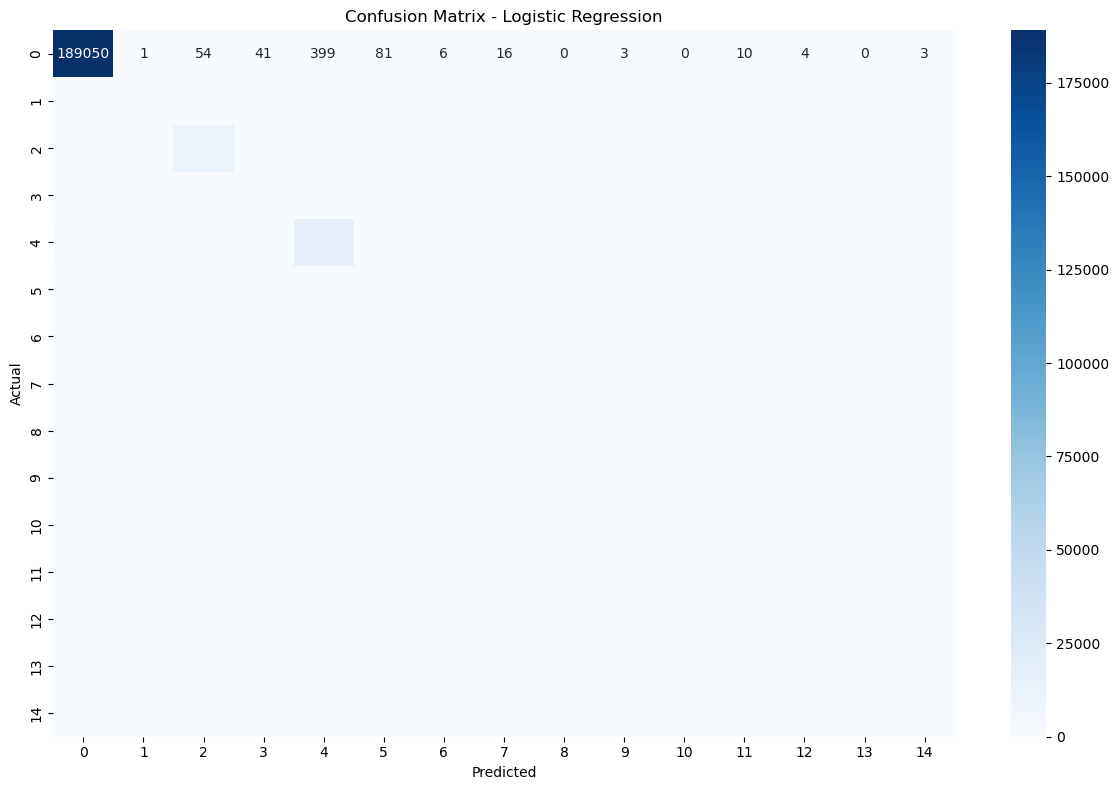


===== Random Forest =====
Training Accuracy: 0.9980
Testing Accuracy: 0.9979


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    189668
           1       0.84      0.58      0.69       144
           2       1.00      1.00      1.00     12801
           3       1.00      0.99      0.99      1029
           4       1.00      0.99      1.00     17285
           5       0.94      0.98      0.96       523
           6       1.00      0.99      0.99       538
           7       1.00      0.99      0.99       593
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         3
          10       0.94      0.87      0.90       196
          11       1.00      0.94      0.97       322
          12       0.69      0.84      0.76       147
          13       0.00      0.00      0.00         2
          14       0.38      0.15      0.22        65

    accuracy                           1.00    223317
   macro avg       0.79      0.75      0.76    223317
weighted avg       1.00   

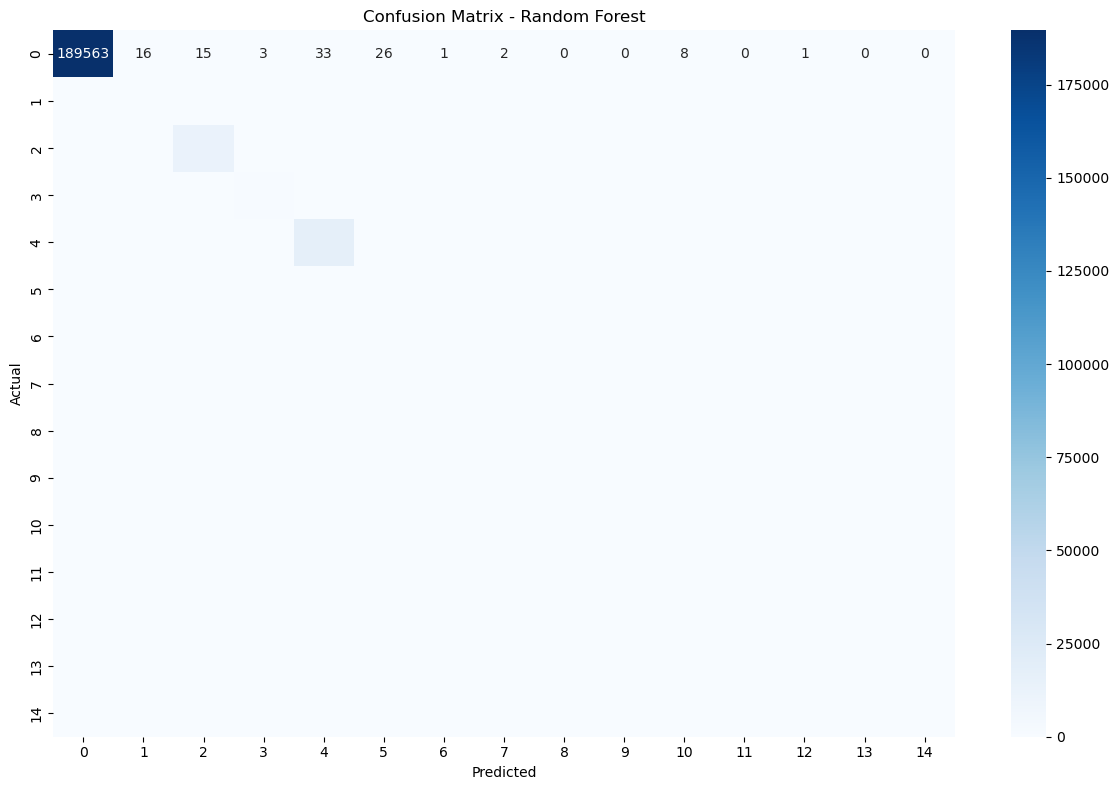


===== XGBoost =====


c:\Users\khush\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:51:44] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 0.9986
Testing Accuracy: 0.9985


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    189668
           1       0.75      0.59      0.66       144
           2       1.00      1.00      1.00     12801
           3       0.99      1.00      0.99      1029
           4       1.00      1.00      1.00     17285
           5       0.95      0.98      0.96       523
           6       0.99      0.99      0.99       538
           7       1.00      0.99      0.99       593
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         3
          10       0.95      0.86      0.90       196
          11       1.00      0.98      0.99       322
          12       0.71      0.69      0.70       147
          13       0.00      0.00      0.00         2
          14       0.34      0.35      0.35        65

    accuracy                           1.00    223317
   macro avg       0.71      0.70      0.70    223317
weighted avg       1.00   

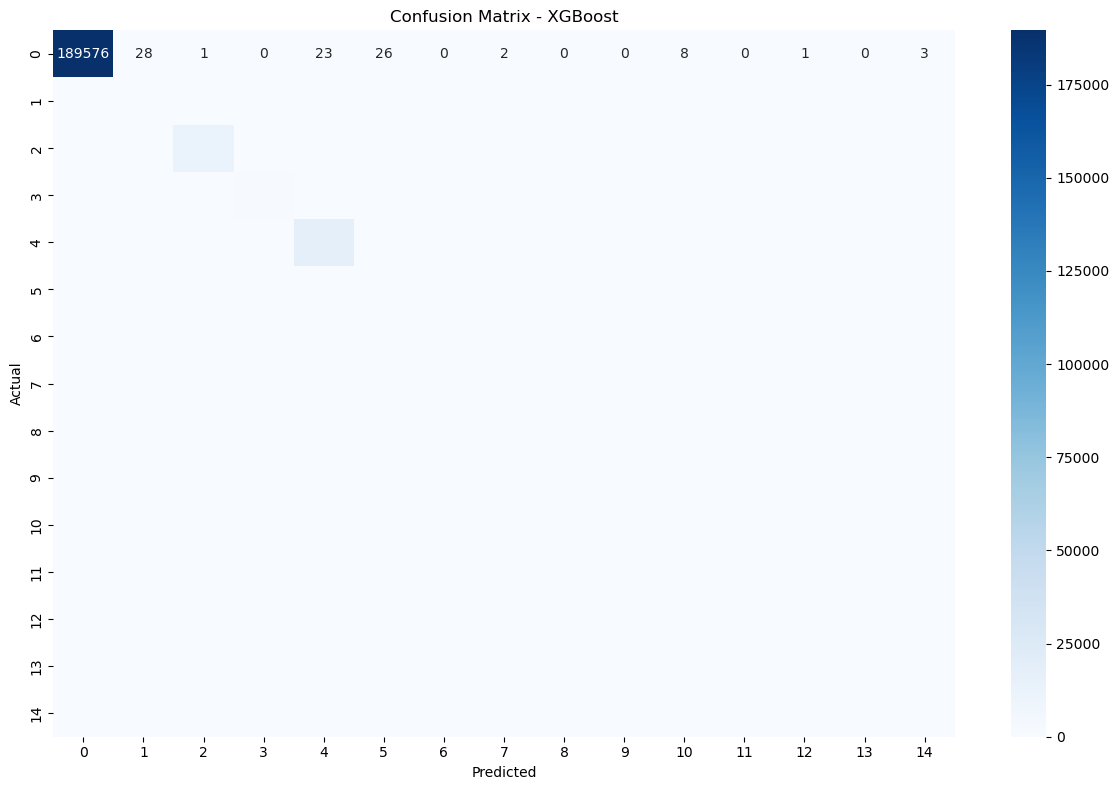


--- Summary of Accuracies ---
                     Training Accuracy  Testing Accuracy
Logistic Regression           0.983029          0.982881
Random Forest                 0.998047          0.997927
XGBoost                       0.998622          0.998478


In [ ]:
# --- Create a directory to save results ---
import os
output_dir = 'model_results'
os.makedirs(output_dir, exist_ok=True)


# --- Define the models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                             n_estimators=100, n_jobs=-1, random_state=42)
}

train_accs, test_accs = {}, {}
classification_reports = {}

# --- Model Training and Evaluation Loop ---
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Train the model on the smaller, sampled dataset
    model.fit(X_train_small, y_train_small)

    # Predict on the full training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accs[name] = train_acc
    test_accs[name] = test_acc

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")

    # --- Generate and Save Classification Report ---
    class_names = [str(c) for c in np.unique(y)]  # Use unique classes from full dataset
    report = classification_report(y_test, y_test_pred, target_names=class_names)
    classification_reports[name] = report
    print(report)

    # Save the report to a text file
    with open(os.path.join(output_dir, f'{name}_classification_report.txt'), 'w') as f:
        f.write(report)

    # --- Generate and Save Confusion Matrix Plot ---
    cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y))
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{name}_confusion_matrix.png'))
    plt.show()

# --- Save final summary of accuracies ---
accuracy_summary = pd.DataFrame({
    'Training Accuracy': train_accs,
    'Testing Accuracy': test_accs
})
accuracy_summary.to_csv(os.path.join(output_dir, 'model_accuracy_summary.csv'))
print("\n--- Summary of Accuracies ---")
print(accuracy_summary)

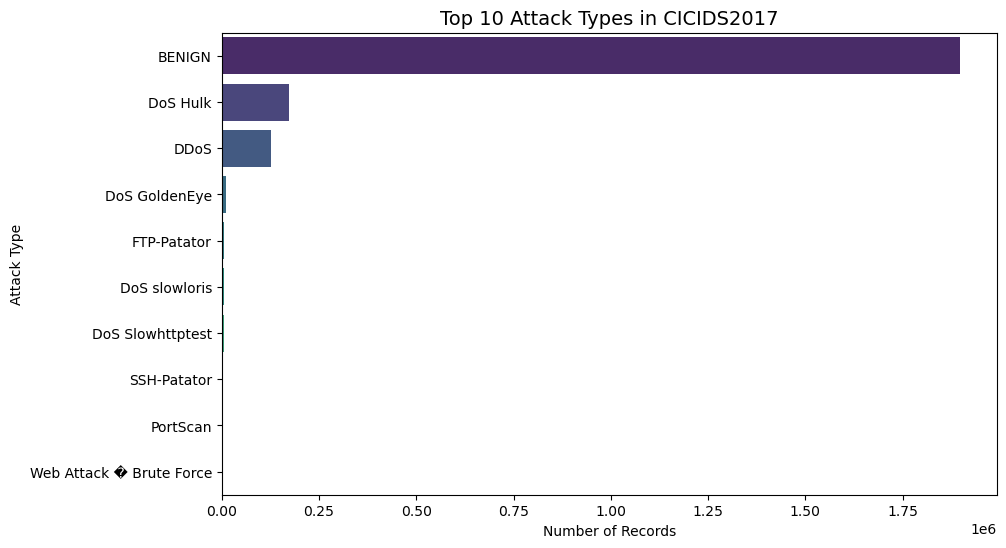

In [ ]:
attack_counts = df["Label"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette="viridis")
plt.title("Top 10 Attack Types in CICIDS2017", fontsize=14)
plt.xlabel("Number of Records")
plt.ylabel("Attack Type")
plt.show()

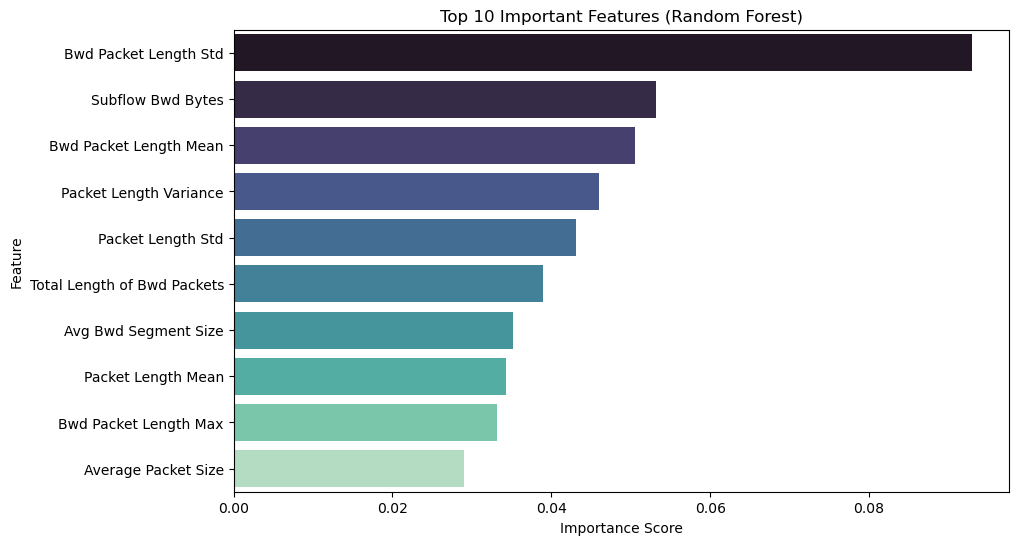

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_small, y_train_small)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_features = X.columns[indices[:10]]
top_importances = importances[indices[:10]]

plt.figure(figsize=(10,6))
sns.barplot(x=top_importances, y=top_features, palette="mako")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()